In [5]:
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. Вариационный ряд

In [3]:
data = [79.02, 74.68, 11.7, 40.75, 96.42,
        91.75, 77.75, 76.59, 6.17, 80.87,
        48.04, 100.46, 94.56, 47.93, 66.79,
        20.27, 62.51, 87.99, 5.96, 62.53,
        46.55, 55.65, 77.05, 29.93, 86.11,
        90.93, 9.76, 36.72, 20.5, 56.29,
        43.61, 80.47, 29.98, 40.37, 91.46,
        90.75, 36.53, 6.99, 30.85, 64.44,
        18, 98.88, 34.64, 10.53, 39.4,
        100.39, 9.27, 65.91, 75.45, 89.74,
        79.7, 20.47, 44.64, 8.59, 6.17,
        93.29, 81.25, 51.84, 42.79, 92.81,
        14.7, 69.83, 70.42, 47.48, 42.12,
        51.36, 66.68, 99.29, 60.38, 75.5,
        83.53, 59.26, 101.1, 102.21, 45.92,
        24.3, 90.25, 84.96, 81.99, 31.75,
        68.7, 100.66, 48.88, 67.46, 59.11,
        4.64, 32.39, 8.41, 37.3, 25.6,
        84.27, 36.39, 49.49, 50.97, 3.59,
        18.57, 10.89, 35.62, 37.86, 4.57]

variational_series = sorted(data)
print(variational_series)

[3.59, 4.57, 4.64, 5.96, 6.17, 6.17, 6.99, 8.41, 8.59, 9.27, 9.76, 10.53, 10.89, 11.7, 14.7, 18, 18.57, 20.27, 20.47, 20.5, 24.3, 25.6, 29.93, 29.98, 30.85, 31.75, 32.39, 34.64, 35.62, 36.39, 36.53, 36.72, 37.3, 37.86, 39.4, 40.37, 40.75, 42.12, 42.79, 43.61, 44.64, 45.92, 46.55, 47.48, 47.93, 48.04, 48.88, 49.49, 50.97, 51.36, 51.84, 55.65, 56.29, 59.11, 59.26, 60.38, 62.51, 62.53, 64.44, 65.91, 66.68, 66.79, 67.46, 68.7, 69.83, 70.42, 74.68, 75.45, 75.5, 76.59, 77.05, 77.75, 79.02, 79.7, 80.47, 80.87, 81.25, 81.99, 83.53, 84.27, 84.96, 86.11, 87.99, 89.74, 90.25, 90.75, 90.93, 91.46, 91.75, 92.81, 93.29, 94.56, 96.42, 98.88, 99.29, 100.39, 100.46, 100.66, 101.1, 102.21]


# 2. Построение интервального статистического ряда

In [6]:
n = len(data)
k = round(1 + 3.322 * math.log10(n))
h = (max(data) - min(data)) / k

bins = [min(data) + i * h for i in range(k + 1)]

freq, intervals = np.histogram(data, bins=bins)

interval_series = []
for i in range(len(freq)):
    lower = intervals[i]
    upper = intervals[i + 1]
    interval_series.append((f"{lower:.2f} - {upper:.2f}", freq[i]))

print("Интервальный статистический ряд:")
print("Интервал\tЧacтoтa")
for interval, count in interval_series:
    print(f"{interval}\t{count}")

Интервальный статистический ряд:
Интервал	Чacтoтa
3.59 - 15.92	15
15.92 - 28.24	7
28.24 - 40.57	14
40.57 - 52.90	15
52.90 - 65.23	8
65.23 - 77.55	12
77.55 - 89.88	13
89.88 - 102.21	16


# 3. Построение полигона

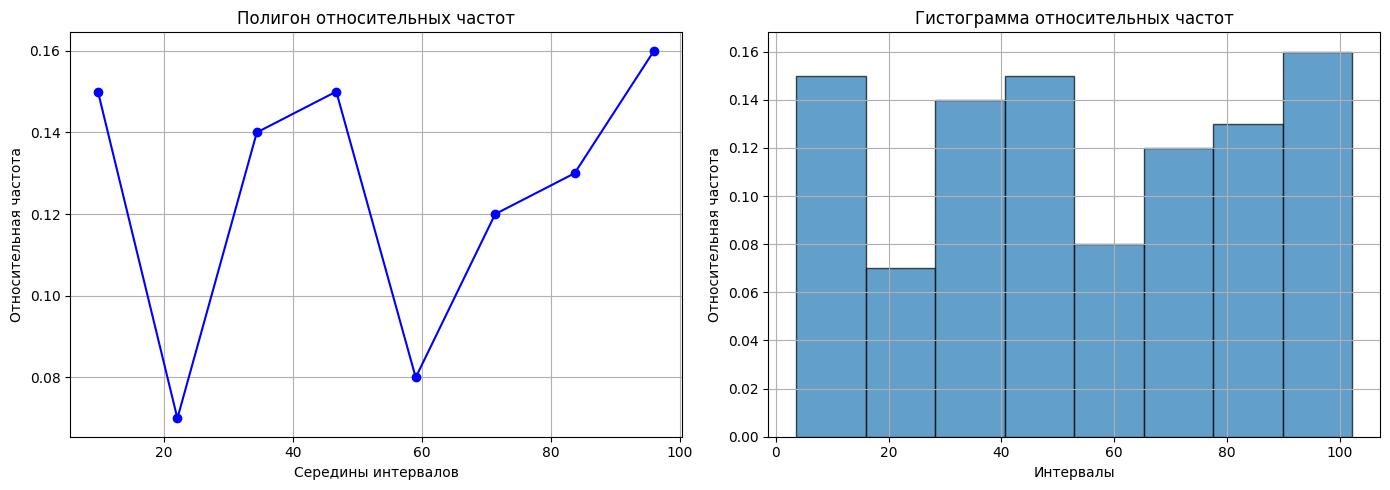

In [7]:
bins = np.linspace(min(data), max(data), k + 1)
freq, _ = np.histogram(data, bins=bins)
rel_freq = freq / n

midpoints = (bins[:-1] + bins[1:]) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Полигон
ax1.plot(midpoints, rel_freq, 'bo-', label='Полигон')
ax1.set_title('Полигон относительных частот')
ax1.set_xlabel('Середины интервалов')
ax1.set_ylabel('Относительная частота')
ax1.grid()

# Гистограмма
ax2.bar(bins[:-1], rel_freq, width=h, edgecolor='black', alpha=0.7, align='edge')
ax2.set_title('Гистограмма относительных частот')
ax2.set_xlabel('Интервалы')
ax2.set_ylabel('Относительная частота')
ax2.grid()

plt.tight_layout()
plt.show()

# 4. Эмпирическая функция распределения

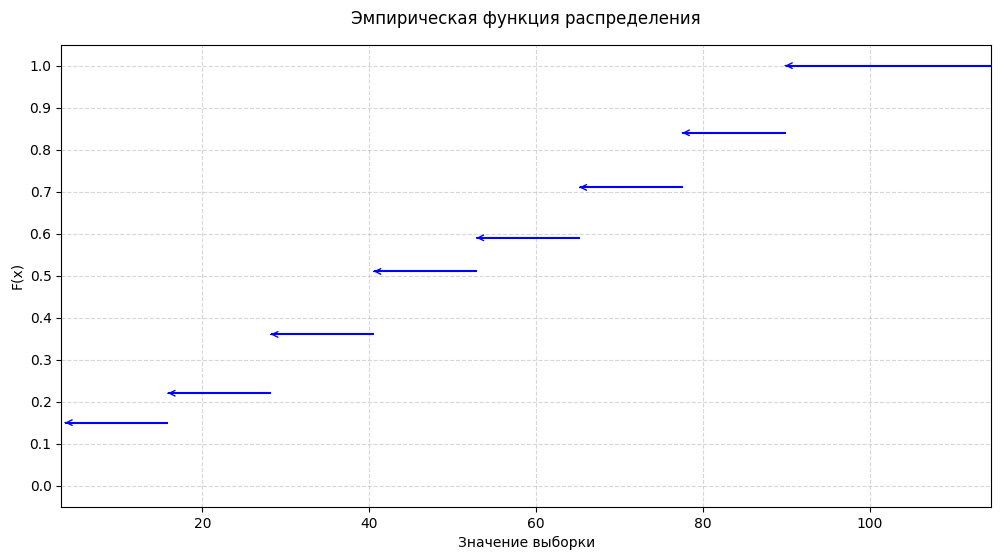

In [21]:
# Построение эмпирической функции распределения
cum_counts = np.cumsum(freq)
y = cum_counts / n

plt.figure(figsize=(12, 6))

# Рисуем горизонтальные линии для каждого интервала
for i in range(len(intervals) - 1):
    start_x = intervals[i]
    end_x = intervals[i + 1]
    
    plt.hlines(y=y[i], xmin=start_x, xmax=end_x, color='blue', linewidth=1.5)
    
    # Добавляем стрелки в начале каждой линии
    plt.annotate('', 
                 xy=(start_x, y[i]), 
                 xytext=(start_x - 0.05, y[i]),
                 arrowprops=dict(arrowstyle='<-', color='blue', lw=1))

# Добавляем последнюю горизонтальную линию (если нужно)
plt.hlines(y=1.0, xmin=intervals[-1], xmax=intervals[-1] + h, color='blue', linewidth=1.5)

plt.title('Эмпирическая функция распределения', pad=15)
plt.xlabel('Значение выборки')
plt.ylabel('F(x)')
plt.grid(True, linestyle='--', alpha=0.5)
#plt.xticks(np.arange(np.floor(min(data)), np.ceil(max(data)) + 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlim(intervals[0] - 0.5, intervals[-1] + h)
plt.ylim(-0.05, 1.05)
plt.show()

# 5. Числовые характеричтики распределения

In [18]:
mean = np.mean(data)
var = np.var(data, ddof=1)
mode = stats.mode(data)
median = np.median(data)
skewness = stats.skew(data)
kurtosis = stats.kurtosis(data, fisher=True)
print(f"1. Выборочное среднее: {np.mean(data):.4f}")
print(f"2. Исправленная выборочная дисперсия: {np.var(data, ddof=1):.4f}")
print(f"3. Мода: {stats.mode(data).mode} (встречается {stats.mode(data).count} раз)")
print(f"4. Медиана: {np.median(data):.1f}")
print(f"5. Коэффициент асимметрии: {stats.skew(data):.4f}")
print(f"6. Коэффициент эксцесса: {stats.kurtosis(data, fisher=True):.4f}")

1. Выборочное среднее: 54.0984
2. Исправленная выборочная дисперсия: 899.6611
3. Мода: 6.17 (встречается 2 раз)
4. Медиана: 51.6
5. Коэффициент асимметрии: -0.0904
6. Коэффициент эксцесса: -1.1988


# 6. Гипотеза о распределении

# 7. Оценки параметров предполагаемого распределения генеральной совокупности

# 8. Построить на чертеже гистограммы и эмпирической функции её теоретические аналоги f(x) и F(x)

# 9. Проверка правила «трех сигм»

# 10. Критерий согласия Пирсона

# 11. Доверительные интервалы

In [7]:
import numpy as np
from scipy import stats

data = np.array([3.0, 5.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0, 2.0, 
                 4.0, 0.0, 3.0, 3.0, 3.0, 3.0, 1.0, 2.0, 3.0, 3.0, 2.0, 2.0, 
                 5.0, 2.0, 4.0, 4.0, 1.0, 2.0, 3.0, 1.0, 4.0, 0.0, 3.0, 5.0, 
                 6.0, 4.0, 8.0, 2.0, 2.0, 5.0, 1.0, 0.0, 1.0, 5.0, 3.0, 2.0, 
                 5.0, 1.0])
n = len(data)

mu_hat = np.mean(data)
sigma_hat = np.std(data, ddof=1)

print(f"Оценка μ: {mu_hat:.4f}")
print(f"Оценка σ: {sigma_hat:.4f}")

Оценка μ: 2.9000
Оценка σ: 1.5940


Интервальный статистический ряд:
Интервал	Частота
5.27 - 6.40	6
6.40 - 7.52	2
7.52 - 8.64	16
8.64 - 9.77	21
9.77 - 10.89	16
10.89 - 12.01	18
12.01 - 13.14	16
13.14 - 14.26	5


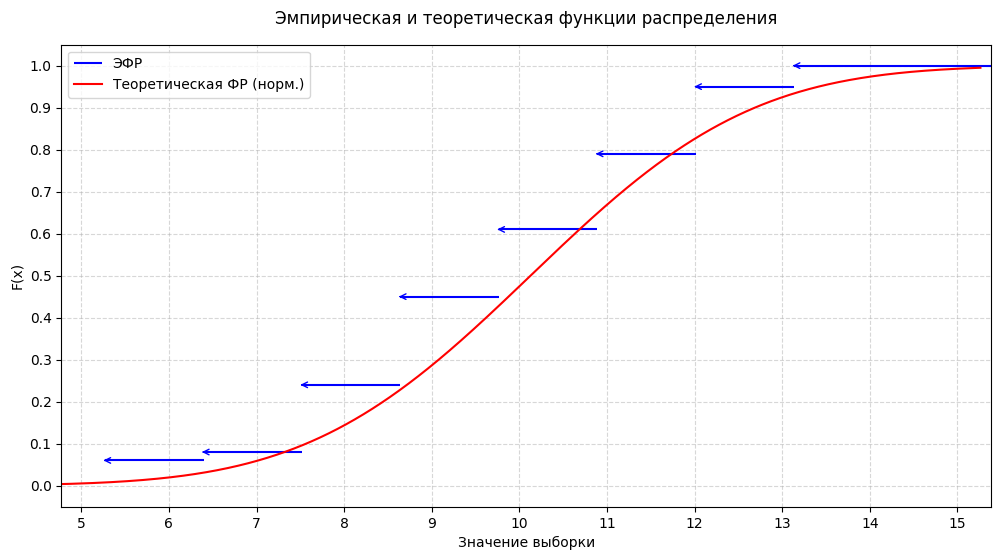

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Данные
data = np.array([79.02, 74.68, 11.7, 40.75, 96.42,
                91.75, 77.75, 76.59, 6.17, 80.87,
                48.04, 100.46, 94.56, 47.93, 66.79,
                20.27, 62.51, 87.99, 5.96, 62.53,
                46.55, 55.65, 77.05, 29.93, 86.11,
                90.93, 9.76, 36.72, 20.5, 56.29,
                43.61, 80.47, 29.98, 40.37, 91.46,
                90.75, 36.53, 6.99, 30.85, 64.44,
                18, 98.88, 34.64, 10.53, 39.4,
                100.39, 9.27, 65.91, 75.45, 89.74,
                79.7, 20.47, 44.64, 8.59, 6.17,
                93.29, 81.25, 51.84, 42.79, 92.81,
                14.7, 69.83, 70.42, 47.48, 42.12,
                51.36, 66.68, 99.29, 60.38, 75.5,
                83.53, 59.26, 101.1, 102.21, 45.92,
                24.3, 90.25, 84.96, 81.99, 31.75,
                68.7, 100.66, 48.88, 67.46, 59.11,
                4.64, 32.39, 8.41, 37.3, 25.6,
                84.27, 36.39, 49.49, 50.97, 3.59,
                18.57, 10.89, 35.62, 37.86, 4.57])
n = len(data)

import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import stats

# Ваши данные (замените на реальные данные)
data = np.random.normal(10, 2, 100)

# Оценка параметров нормального распределения
mu_hat = np.mean(data)
sigma_hat = np.std(data)

# Разбиение на интервалы
n = len(data)
k = round(1 + 3.322 * math.log10(n))
h = (max(data) - min(data)) / k
bins = [min(data) + i * h for i in range(k + 1)]

# Подсчет частот
freq, intervals = np.histogram(data, bins=bins)

# Создание интервального ряда
interval_series = []
for i in range(len(freq)):
    lower = intervals[i]
    upper = intervals[i + 1]
    interval_series.append((f"{lower:.2f} - {upper:.2f}", freq[i]))

# Вывод интервального ряда
print("Интервальный статистический ряд:")
print("Интервал\tЧастота")
for interval, count in interval_series:
    print(f"{interval}\t{count}")

# Построение эмпирической функции распределения
cum_counts = np.cumsum(freq)
y = cum_counts / n

# Теоретическая функция распределения
x_vals_ecdf = np.linspace(min(data)-1, max(data)+1, 1000)
cdf_vals = stats.norm.cdf(x_vals_ecdf, mu_hat, sigma_hat)

# Создание графика
plt.figure(figsize=(12, 6))

# ЭФР (ступенчатая функция)
for i in range(len(intervals) - 1):
    start_x = intervals[i]
    end_x = intervals[i + 1]
    
    plt.hlines(y=y[i], xmin=start_x, xmax=end_x, color='blue', linewidth=1.5, 
              label='ЭФР' if i == 0 else "")
    
    # Добавляем стрелки в начале каждой линии
    plt.annotate('', 
                 xy=(start_x, y[i]), 
                 xytext=(start_x - 0.05, y[i]),
                 arrowprops=dict(arrowstyle='<-', color='blue', lw=1))

# Добавляем последнюю горизонтальную линию
plt.hlines(y=1.0, xmin=intervals[-1], xmax=intervals[-1] + h, color='blue', linewidth=1.5)

# Теоретическая ФР (гладкая кривая)
plt.plot(x_vals_ecdf, cdf_vals, 'r-', label='Теоретическая ФР (норм.)')

# Настройки графика
plt.title('Эмпирическая и теоретическая функции распределения', pad=15)
plt.xlabel('Значение выборки')
plt.ylabel('F(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(np.floor(min(data)), np.ceil(max(data)) + 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlim(intervals[0] - 0.5, intervals[-1] + h)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

In [24]:
within_1sigma = np.sum((data >= mu_hat - sigma_hat) & (data <= mu_hat + sigma_hat)) / n * 100
within_2sigma = np.sum((data >= mu_hat - 2*sigma_hat) & (data <= mu_hat + 2*sigma_hat)) / n * 100
within_3sigma = np.sum((data >= mu_hat - 3*sigma_hat) & (data <= mu_hat + 3*sigma_hat)) / n * 100

print(f"Данных в μ ± σ: {within_1sigma:.1f}% (ожидается ~68%)")
print(f"Данных в μ ± 2σ: {within_2sigma:.1f}% (ожидается ~95%)")
print(f"Данных в μ ± 3σ: {within_3sigma:.1f}% (ожидается ~99.7%)")

Данных в μ ± σ: 64.0% (ожидается ~68%)
Данных в μ ± 2σ: 93.0% (ожидается ~95%)
Данных в μ ± 3σ: 100.0% (ожидается ~99.7%)


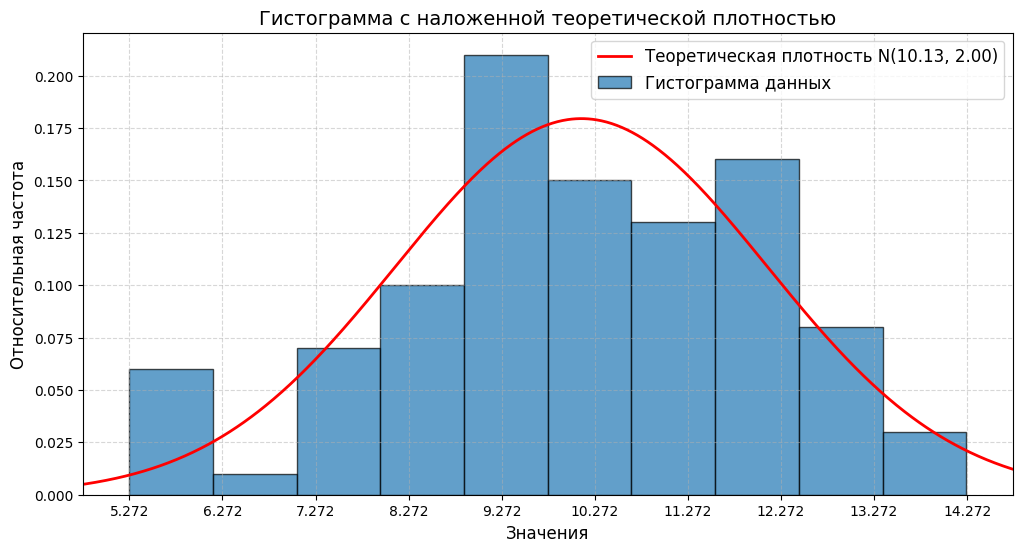

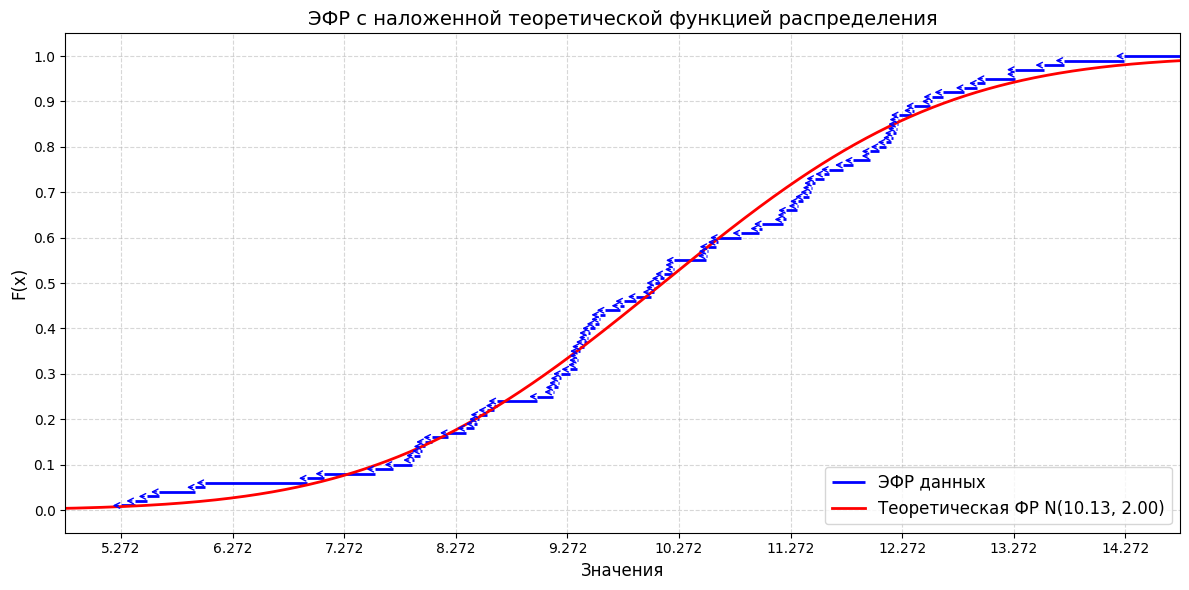

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =============================================
# 1. ГИСТОГРАММА + ТЕОРЕТИЧЕСКАЯ ПЛОТНОСТЬ
# =============================================
plt.figure(figsize=(12, 6))

# Ваш код для гистограммы (с небольшими изменениями)
k = 10
h = (max(data) - min(data)) / k
bins = np.linspace(min(data), max(data), k + 1)
freq, _ = np.histogram(data, bins=bins)
rel_freq = freq / n

# Ваша гистограмма
plt.bar(bins[:-1], rel_freq, width=h, edgecolor='black', 
        alpha=0.7, align='edge', label='Гистограмма данных')

# Теоретическая плотность нормального распределения
x = np.linspace(min(data)-1, max(data)+1, 1000)
pdf = stats.norm.pdf(x, mu_hat, sigma_hat) * h  # Масштабируем для соответствия гистограмме
plt.plot(x, pdf, 'r-', linewidth=2, label='Теоретическая плотность N(%.2f, %.2f)' % (mu_hat, sigma_hat))

plt.title('Гистограмма с наложенной теоретической плотностью', fontsize=14)
plt.xlabel('Значения', fontsize=12)
plt.ylabel('Относительная частота', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(min(data), max(data)+1))
plt.xlim(min(data)-0.5, max(data)+0.5)

# =============================================
# 2. ЭФР + ТЕОРЕТИЧЕСКАЯ ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ
# =============================================
plt.figure(figsize=(12, 6))

# Ваш код для ЭФР (с небольшими изменениями)
sorted_data = np.sort(data)
unique_vals, counts = np.unique(sorted_data, return_counts=True)
cum_counts = np.cumsum(counts)
y = cum_counts / n

# Ваша ЭФР
for i in range(len(unique_vals)):
    start_x = unique_vals[i]
    end_x = unique_vals[i+1] if i < len(unique_vals)-1 else unique_vals[-1]+1
    plt.hlines(y=y[i], xmin=start_x, xmax=end_x, color='blue', linewidth=2, 
               label='ЭФР данных' if i == 0 else "")
    plt.annotate('', xy=(start_x, y[i]), xytext=(start_x-0.1, y[i]),
                 arrowprops=dict(arrowstyle='<-', color='blue', lw=1))

# Теоретическая функция распределения
x = np.linspace(min(data)-1, max(data)+1, 1000)
cdf = stats.norm.cdf(x, mu_hat, sigma_hat)
plt.plot(x, cdf, 'r-', linewidth=2, label='Теоретическая ФР N(%.2f, %.2f)' % (mu_hat, sigma_hat))

plt.title('ЭФР с наложенной теоретической функцией распределения', fontsize=14)
plt.xlabel('Значения', fontsize=12)
plt.ylabel('F(x)', fontsize=12)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(min(data), max(data)+1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlim(min(data)-0.5, max(data)+0.5)
plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [28]:
import numpy as np
from scipy import stats

data = np.array([79.02, 74.68, 11.7, 40.75, 96.42,
                91.75, 77.75, 76.59, 6.17, 80.87,
                48.04, 100.46, 94.56, 47.93, 66.79,
                20.27, 62.51, 87.99, 5.96, 62.53,
                46.55, 55.65, 77.05, 29.93, 86.11,
                90.93, 9.76, 36.72, 20.5, 56.29,
                43.61, 80.47, 29.98, 40.37, 91.46,
                90.75, 36.53, 6.99, 30.85, 64.44,
                18, 98.88, 34.64, 10.53, 39.4,
                100.39, 9.27, 65.91, 75.45, 89.74,
                79.7, 20.47, 44.64, 8.59, 6.17,
                93.29, 81.25, 51.84, 42.79, 92.81,
                14.7, 69.83, 70.42, 47.48, 42.12,
                51.36, 66.68, 99.29, 60.38, 75.5,
                83.53, 59.26, 101.1, 102.21, 45.92,
                24.3, 90.25, 84.96, 81.99, 31.75,
                68.7, 100.66, 48.88, 67.46, 59.11,
                4.64, 32.39, 8.41, 37.3, 25.6,
                84.27, 36.39, 49.49, 50.97, 3.59,
                18.57, 10.89, 35.62, 37.86, 4.57])

n = len(data)
alpha = 0.05
mu_hat = np.mean(data)
sigma_hat = np.std(data, ddof=1)

# Заданные интервалы
bins = [3.59, 15.92, 28.24, 40.57, 52.90, 65.23, 77.55, 89.88, 102.21]

# Подсчет частот
observed, _ = np.histogram(data, bins=bins)
expected = n * np.diff(stats.norm.cdf(bins, mu_hat, sigma_hat))

# Проверка ожидаемых частот (должны быть ≥5)
print("Проверка ожидаемых частот:")
for i in range(len(expected)):
    print(f"Интервал {i+1}: ожидаемая частота = {expected[i]:.2f}")

# Критерий Пирсона
chi2_stat = np.sum((observed - expected)**2 / expected)
df = len(observed) - 3  # 3 параметра: μ, σ и общее количество наблюдений
critical_value_chi2 = stats.chi2.ppf(1 - alpha, df)
p_value_chi2 = 1 - stats.chi2.cdf(chi2_stat, df)

# Вывод оценок параметров
print(f"\nОценки параметров:\nμ = {mu_hat:.4f}, σ = {sigma_hat:.4f}\n")

# Таблица для критерия Пирсона
print("Интервальный статистический ряд:")
print("Интервал\t\tНаблюдаемая\tОжидаемая\t(O-E)²/E")
print("-"*65)
for i in range(len(observed)):
    left = bins[i]
    right = bins[i+1]
    contribution = (observed[i] - expected[i])**2 / expected[i]
    print(f"[{left:6.2f}, {right:6.2f})\t{observed[i]:8d}\t{expected[i]:10.2f}\t{contribution:8.4f}")

# Итоговые значения критерия Пирсона
print("\n" + "-"*65)
print(f"Сумма (χ² статистика):\t\t\t\t{chi2_stat:.4f}")
print(f"Критическое значение (α={alpha}, df={df}):\t{critical_value_chi2:.4f}")
print(f"p-value:\t\t\t\t\t{p_value_chi2:.4f}")

# Интерпретация результата
print("\nВывод:")
if chi2_stat > critical_value_chi2:
    print(f"Отвергаем нулевую гипотезу (χ² = {chi2_stat:.4f} > {critical_value_chi2:.4f})")
    print("Распределение не является нормальным с параметрами μ={:.4f}, σ={:.4f}".format(mu_hat, sigma_hat))
else:
    print(f"Не отвергаем нулевую гипотезу (χ² = {chi2_stat:.4f} ≤ {critical_value_chi2:.4f})")
    print("Данные согласуются с нормальным распределением с параметрами μ={:.4f}, σ={:.4f}".format(mu_hat, sigma_hat))

Проверка ожидаемых частот:
Интервал 1: ожидаемая частота = 5.54
Интервал 2: ожидаемая частота = 9.28
Интервал 3: ожидаемая частота = 13.17
Интервал 4: ожидаемая частота = 15.81
Интервал 5: ожидаемая частота = 16.07
Интервал 6: ожидаемая частота = 13.81
Интервал 7: ожидаемая частота = 10.07
Интервал 8: ожидаемая частота = 6.21

Оценки параметров:
μ = 54.0984, σ = 29.9944

Интервальный статистический ряд:
Интервал		Наблюдаемая	Ожидаемая	(O-E)²/E
-----------------------------------------------------------------
[  3.59,  15.92)	      15	      5.54	 16.1300
[ 15.92,  28.24)	       7	      9.28	  0.5593
[ 28.24,  40.57)	      14	     13.17	  0.0527
[ 40.57,  52.90)	      15	     15.81	  0.0413
[ 52.90,  65.23)	       8	     16.07	  4.0497
[ 65.23,  77.55)	      12	     13.81	  0.2379
[ 77.55,  89.88)	      13	     10.07	  0.8525
[ 89.88, 102.21)	      16	      6.21	 15.4389

-----------------------------------------------------------------
Сумма (χ² статистика):				37.3623
Критическое значе

In [12]:
gamma = 0.95
alpha = 1 - gamma

t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
ci_mean = (mu_hat - t_critical * sigma_hat / np.sqrt(n), mu_hat + t_critical * sigma_hat / np.sqrt(n))

chi2_lower = stats.chi2.ppf(1 - alpha/2, df=n-1)
chi2_upper = stats.chi2.ppf(alpha/2, df=n-1)
ci_std = (np.sqrt((n-1) * sigma_hat**2 / chi2_lower), np.sqrt((n-1) * sigma_hat**2 / chi2_upper))

print(f"Доверительный интервал для μ (γ={gamma}): ({ci_mean[0]:.4f}; {ci_mean[1]:.4f})")
print(f"Доверительный интервал для σ (γ={gamma}): ({ci_std[0]:.4f}; {ci_std[1]:.4f})")

Доверительный интервал для μ (γ=0.95): (2.4470; 3.3530)
Доверительный интервал для σ (γ=0.95): (1.3315; 1.9863)
